In [1]:
import sys
import os
import matplotlib.pyplot as plt
# Add the project root to the Python path
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

from crater_analysis.io import read_crater_locations, read_dem
from crater_analysis.analysis import filter_craters, get_crater_profile, get_dem_snippet
from crater_analysis.plotting import plot_dem, plot_crater_locations
from crater_analysis.core import Crater


dem, metadata = read_dem('../data/dems/LDEM_60S_120M.JP2')

craters = read_crater_locations('../data/catalogs/lunar_crater_database_robbins_2018.csv')
craters = filter_craters(craters, pole='south', lat_threshold=60, circ_threshold=None, diam_min=8, diam_max=None, lat_col='LAT_CIRC_IMG', diam_col='DIAM_CIRC_IMG')

#craters = read_crater_locations('../data/catalogs/moon_data.csv')
#craters = filter_craters(craters, pole='south', lat_threshold=60, circ_threshold=0.85, diam_min=8000, diam_max=None, lat_col='lat', diam_col='diameter_m')

craters.head()

Successfully read DEM from ../data/dems/LDEM_60S_120M.JP2
Successfully read 1296796 crater locations from ../data/catalogs/lunar_crater_database_robbins_2018.csv
Filtered to 2511 craters matching criteria.
Successfully read 1296796 crater locations from ../data/catalogs/lunar_crater_database_robbins_2018.csv
Filtered to 2511 craters matching criteria.


,CRATER_ID,LAT_CIRC_IMG,LON_CIRC_IMG,LAT_ELLI_IMG,LON_ELLI_IMG,DIAM_CIRC_IMG,DIAM_CIRC_SD_IMG,DIAM_ELLI_MAJOR_IMG,DIAM_ELLI_MINOR_IMG,DIAM_ELLI_ECCEN_IMG,...,DIAM_ELLI_ANGLE_IMG,LAT_ELLI_SD_IMG,LON_ELLI_SD_IMG,DIAM_ELLI_MAJOR_SD_IMG,DIAM_ELLI_MINOR_SD_IMG,DIAM_ELLI_ANGLE_SD_IMG,DIAM_ELLI_ECCEN_SD_IMG,DIAM_ELLI_ELLIP_SD_IMG,ARC_IMG,PTS_RIM_IMG
22,00-1-000022,-69.0838,111.7080,-69.6198,112.8180,296.91100,8.236020,349.56300,292.90900,0.545778,...,126.9250,0.116851,0.302118,11.312900,1.653770,1.838590,0.042263,0.039206,0.273877,245
392503,03-1-161306,-60.0159,240.2810,-60.0299,240.2960,16.14920,0.627066,17.96500,15.11360,0.540602,...,127.8280,0.004110,0.004630,0.301956,0.134482,2.985280,0.024898,0.022606,0.793966,91
650324,07-1-002670,-60.1712,69.8990,-60.1545,69.8455,34.37330,0.844505,35.47040,31.47940,0.460837,...,53.7096,0.002239,0.003996,0.118923,0.183363,1.276750,0.011487,0.007573,0.656386,271
827677,07-1-227330,-60.0047,41.5605,-60.0037,41.5823,8.59538,0.182044,8.86766,7.56926,0.520961,...,91.1537,0.000970,0.002900,0.046377,0.093363,2.451100,0.018737,0.015696,0.663200,36
828210,07-2-000103,-60.2111,11.7462,-60.3188,12.2347,56.42690,2.279950,60.89500,40.27900,0.749990,...,89.8699,0.006955,0.014686,0.437777,0.470050,0.769305,0.007996,0.020722,0.276096,190


In [2]:
### Initialise Craters ###
# Create an empty list to hold the Crater objects
crater_objects = []

# Loop through the first few rows of the DataFrame for demonstration
# To process all craters, change `craters.head(1).iterrows()` to `craters.iterrows()`
for index, row in craters.head(100).iterrows():
    # Extract crater properties from the row
    crater_id = None #row['CRATER_ID']
    crater_lon = row['LON_ELLI_IMG']
    crater_lat = row['LAT_ELLI_IMG']
    crater_diam_km = row['DIAM_ELLI_MAJOR_IMG'] #/1000.0  # Convert diameter from meters to kilometers
    
    # Get the DEM snippet for this crater
    dem_snippet, snippet_meta, center_coords = get_dem_snippet(
        dem,
        metadata,
        crater_lon,
        crater_lat,
        crater_diam_km
    )
    
    # Create the Crater object
    crater_obj = Crater(
        crater_id=crater_id,
        dem_snippet=dem_snippet,
        metadata=snippet_meta,
        center_coords=center_coords,
        global_coords={'lon': crater_lon, 'lat': crater_lat},
    )
    
    crater_obj.add_property('diameter_km', crater_diam_km)

    # Add the new object to our list
    crater_objects.append(crater_obj)

# Print a summary to confirm it worked
print(f"Successfully initialized {len(crater_objects)} Crater objects.")
if crater_objects:
    print("First crater object in the list:")
    print(crater_objects[0])
    print(crater_objects[0].dem_data)
print(dem)

Successfully initialized 100 Crater objects.
First crater object in the list:
Crater(id=None, center=(2184.51103091219, 2184.628324158799), global_coords={'lon': 112.818, 'lat': -69.6198}, properties=['diameter_km'])
[[ 5442  5431  5420 ... -2991 -3016 -3039]
 [ 5435  5430  5432 ... -3036 -3063 -3085]
 [ 5441  5433  5440 ... -3078 -3107 -3131]
 ...
 [-3034 -2989 -2948 ... -1989 -1979 -1979]
 [-2930 -2903 -2872 ... -1981 -1973 -1974]
 [-2844 -2820 -2798 ... -1974 -1966 -1963]]
[[ 1111  1107  1100 ...   118   127   132]
 [ 1122  1116  1108 ...   100   108   107]
 [ 1136  1128  1117 ...    72    77    77]
 ...
 [-7393 -7374 -7350 ... -2913 -2915 -2914]
 [-7407 -7387 -7361 ... -2920 -2918 -2917]
 [-7420 -7396 -7369 ... -2919 -2917 -2919]]


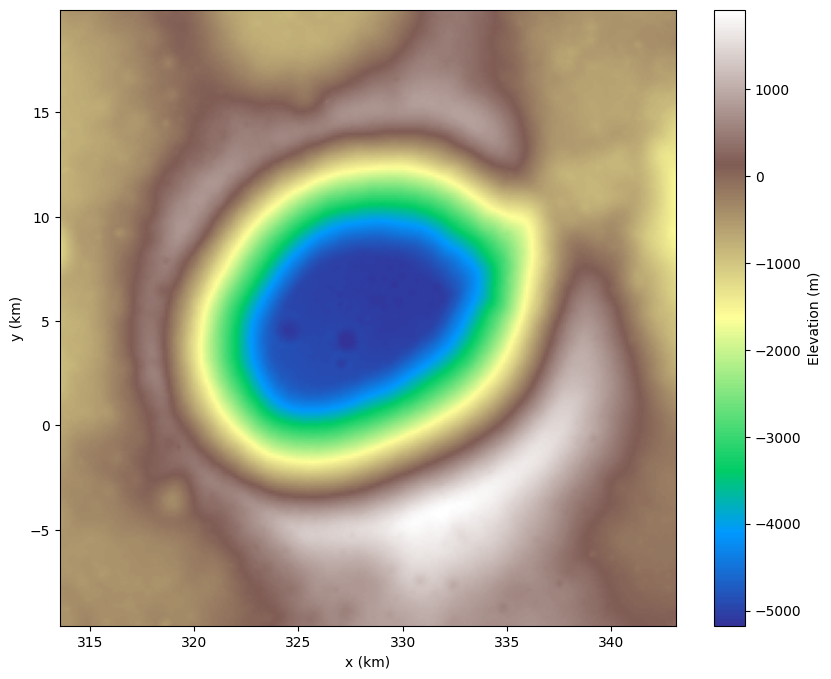

(<Figure size 1000x800 with 2 Axes>, <Axes: xlabel='x (km)', ylabel='y (km)'>)

In [3]:
plot_dem(crater_objects[50].dem_data, crater_objects[0].metadata)

## Extract a 2D Profile from a Crater

The `get_crater_profile` function uses Bresenham's line algorithm to sample actual pixel values along the profile, giving you the true DEM resolution without any interpolation.

Parameters:
- `dem_data`: The DEM array (can be the full DEM or a snippet)
- `metadata`: The corresponding metadata
- `crater_lon`, `crater_lat`: The crater's center coordinates
- `crater_diam_km`: The crater's diameter in kilometers
- `angle`: Angle of the profile in degrees (0=horizontal/E-W, 90=vertical/N-S)

Horizontal profile: 246 pixels
Vertical profile: 246 pixels


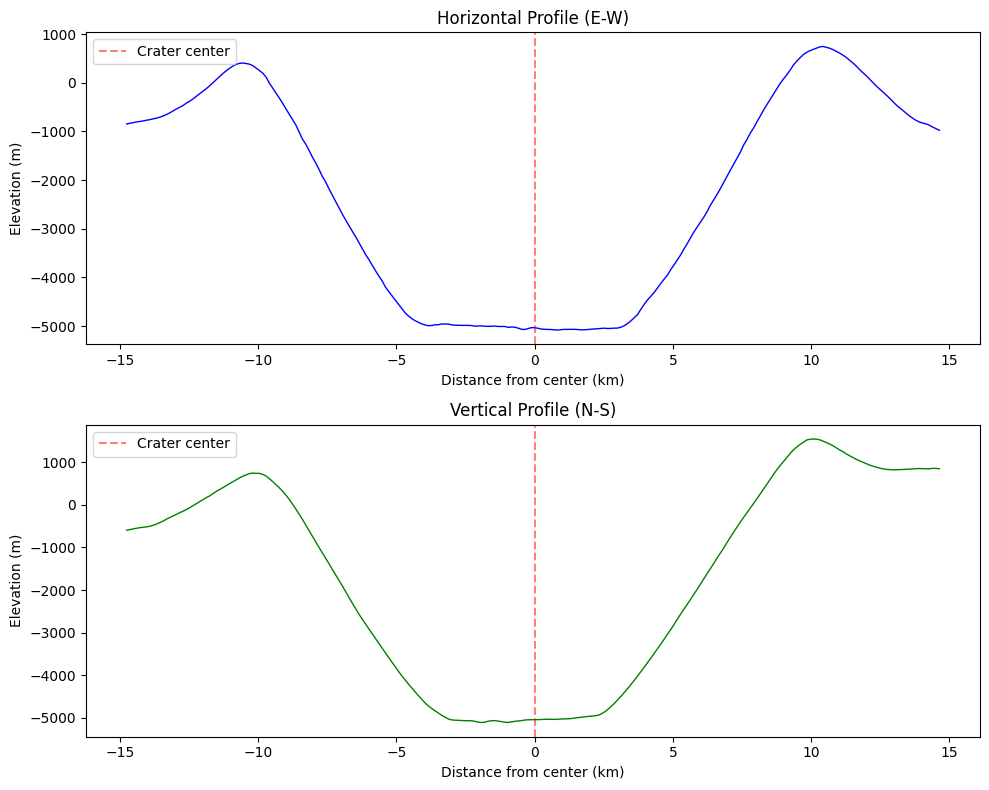

In [10]:
# Extract profiles in both horizontal and vertical directions
crater = crater_objects[50]

# Horizontal profile (E-W, angle=0)
distance_h, elevation_h, pixel_coords_h = get_crater_profile(
    crater.dem_data,
    crater.metadata,
    crater.global_coords['lon'],
    crater.global_coords['lat'],
    crater_diam_km=crater.get_property('diameter_km') * 1.5,
    angle=0  # 0 degrees = horizontal (E-W)
)

# Vertical profile (N-S, angle=90)
distance_v, elevation_v, pixel_coords_v = get_crater_profile(
    crater.dem_data,
    crater.metadata,
    crater.global_coords['lon'],
    crater.global_coords['lat'],
    crater_diam_km=crater.get_property('diameter_km') * 1.5,
    angle=90  # 90 degrees = vertical (N-S)
)

print(f"Horizontal profile: {len(elevation_h)} pixels")
print(f"Vertical profile: {len(elevation_v)} pixels")

# Plot both profiles
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Horizontal profile
ax1.plot(distance_h, elevation_h, '-', linewidth=1, color='blue')
ax1.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Crater center')
ax1.set_xlabel('Distance from center (km)')
ax1.set_ylabel('Elevation (m)')
ax1.set_title(f'Horizontal Profile (E-W)')
#ax1.grid(True, alpha=0.3)
ax1.legend()

# Vertical profile
ax2.plot(distance_v, elevation_v, '-', linewidth=1, color='green')
ax2.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Crater center')
ax2.set_xlabel('Distance from center (km)')
ax2.set_ylabel('Elevation (m)')
ax2.set_title(f'Vertical Profile (N-S)')
#ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()